# Preheating in $\alpha$-attractor models: CosmoLattice runs

Plots of one lattice run for each new model:

| Run | Model | Parameters | Daughter coupling |
|---|---|---|---|
| `E_starobinsky_gw` | `attractorE` (E-model) | $\alpha=1$, $k=2$, $\kappa=1$ (Starobinsky), $N_*=50$, $\lambda=1.89\times10^{-10}$ | $g=4.5\times10^{-3}$, $q_0\simeq10^4$ |
| `T_k2_a1_gw` | `attractorT` (T-model) | $\alpha=1$, $k=2$, $\kappa=1$, $N_*=50$, $\lambda=2.08\times10^{-10}$ | $g=1.7\times10^{-3}$, $q_0\simeq10^4$ |

Both runs start at the end of inflation ($\varepsilon_H=1$), with GWs on. Interaction: $\tfrac12 g^2\varphi^2\chi^2$, with $q_0=g^2\Phi_i^2/(4m^2)$.
Lattice: $N=64$, $k_{\rm IR}=0.5\,\omega_*$, $dt=0.01$, $\tilde t_{\max}=300$.

**Program units** (see `notes/implementation_report.tex`): $\tilde\varphi=\varphi/M_P$, $\omega_*=m_\varphi$ (for $k=2$), time $\tilde t=\omega_* t$ (since $\alpha_t=0$ for $k=2$).
Energy densities are in units of $M_P^2\omega_*^2$. Spectra use `PS_type = 1`, i.e. $\Delta_f(k)=\frac{k^3}{2\pi^2}\,|f_k|^2$ (power per $\ln k$).
The GW spectrum is $\Omega_{\rm GW}(k)\equiv\frac{1}{\rho_{\rm tot}}\frac{d\rho_{\rm GW}}{d\ln k}$, evaluated at the time of the simulation, with no redshifting to today.

In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import cm, colors

plt.rcParams.update({"figure.dpi": 110, "font.size": 11, "axes.grid": True, "grid.alpha": 0.3})

BASE = os.path.abspath(".")  # notebook lives in cosmolattice/runs
RUNS = {
    "E-model (Starobinsky), g=4.5e-3": os.path.join(BASE, "E_starobinsky_gw"),
    "T-model k=2, g=1.7e-3": os.path.join(BASE, "T_k2_a1_gw"),
}


def load_table(path):
    # CosmoLattice average_*.txt: header line starting with '#', whitespace separated.
    with open(path) as f:
        header = f.readline().lstrip("#").split()
    data = np.loadtxt(path, comments="#", ndmin=2)
    return {h: data[:, i] for i, h in enumerate(header)}


def load_spectra(path, times_path):
    # spectra_*.txt: one header line, then one block per output time separated by blank lines.
    # Columns: k, value(s)..., multiplicity.
    blocks, cur = [], []
    with open(path) as f:
        f.readline()
        for line in f:
            if line.strip():
                cur.append([float(x) for x in line.split()])
            elif cur:
                blocks.append(np.array(cur)); cur = []
    if cur:
        blocks.append(np.array(cur))
    times = np.loadtxt(times_path, comments="#", ndmin=1)
    n = min(len(blocks), len(times))
    return times[:n], blocks[:n]


def load_run(d):
    r = {}
    r["E"] = load_table(os.path.join(d, "average_energies.txt"))
    r["GW"] = load_table(os.path.join(d, "average_energies_gws.txt"))
    r["a"] = load_table(os.path.join(d, "average_scale_factor.txt"))
    r["cons"] = load_table(os.path.join(d, "average_energy_conservation.txt"))
    r["phi"] = load_table(os.path.join(d, "average_scalar_0.txt"))
    r["chi"] = load_table(os.path.join(d, "average_scalar_1.txt"))
    st = os.path.join(d, "average_spectra_times.txt")
    r["t_s"], r["S_phi"] = load_spectra(os.path.join(d, "spectra_scalar_0.txt"), st)
    _, r["S_chi"] = load_spectra(os.path.join(d, "spectra_scalar_1.txt"), st)
    _, r["S_gw"] = load_spectra(os.path.join(d, "spectra_energy_gws.txt"), st)
    return r


data = {name: load_run(d) for name, d in RUNS.items()}
for name, r in data.items():
    print(f"{name}: t_max = {r['E']['t'][-1]:.1f}, a_final = {r['a']['a'][-1]:.2f}, "
          f"{len(r['t_s'])} spectra, final rho_GW/rho = {r['GW']['rhoGW_over_rho'][-1]:.2e}")

E-model (Starobinsky), g=4.5e-3: t_max = 299.5, a_final = 19.20, 30 spectra, final rho_GW/rho = 7.76e-05
T-model k=2, g=1.7e-3: t_max = 299.5, a_final = 26.56, 30 spectra, final rho_GW/rho = 1.01e-04


## 1. Homogeneous inflaton, daughter variance and scale factor

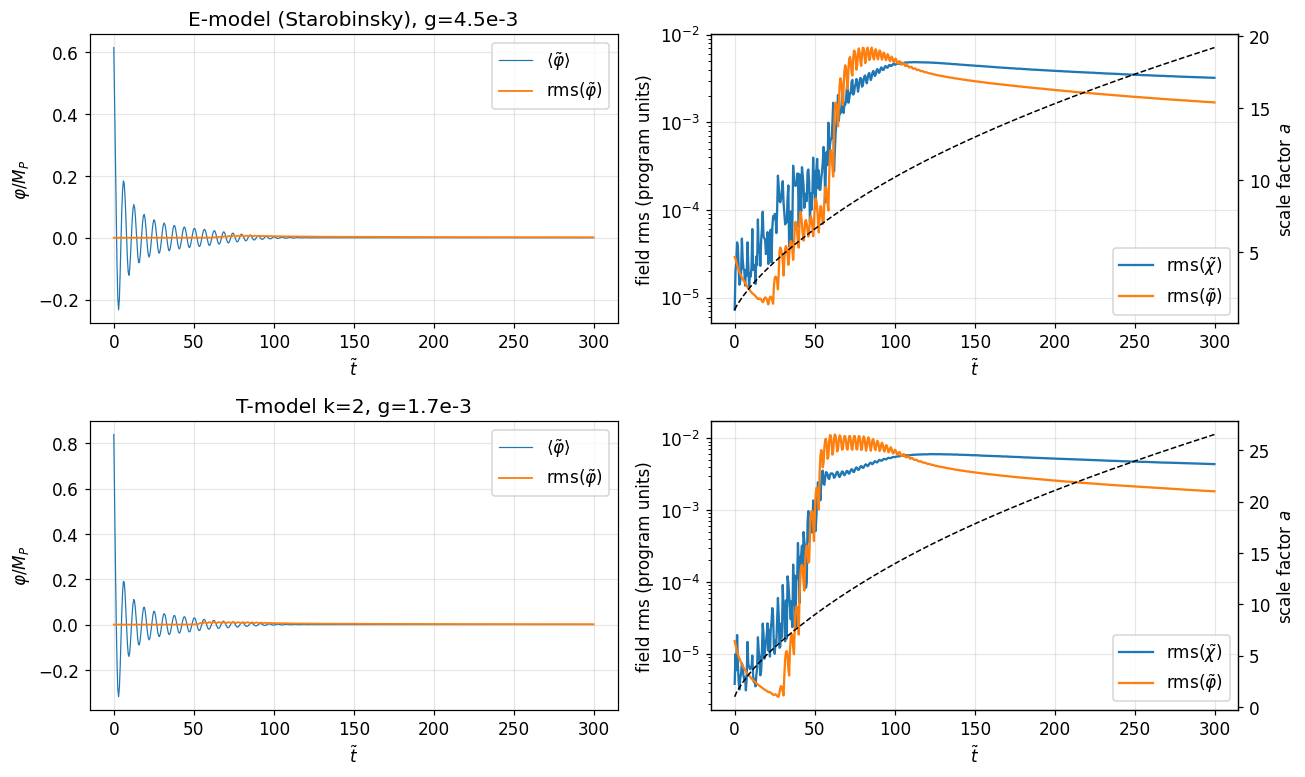

In [2]:
fig, axes = plt.subplots(len(data), 2, figsize=(12, 3.6 * len(data)), squeeze=False)
for row, (name, r) in zip(axes, data.items()):
    ax = row[0]
    ax.plot(r["phi"]["t"], r["phi"]["<phi>"], lw=0.8, label=r"$\langle\tilde\varphi\rangle$")
    ax.plot(r["phi"]["t"], r["phi"]["rms(phi)"], lw=1.2, label=r"rms$(\tilde\varphi)$")
    ax.set_xlabel(r"$\tilde t$"); ax.set_ylabel(r"$\varphi/M_P$"); ax.set_title(name); ax.legend()
    ax = row[1]
    ax.semilogy(r["chi"]["t"], r["chi"]["rms(phi)"], label=r"rms$(\tilde\chi)$")
    ax.semilogy(r["phi"]["t"], r["phi"]["rms(phi)"], label=r"rms$(\tilde\varphi)$")
    ax2 = ax.twinx(); ax2.grid(False)
    ax2.plot(r["a"]["t"], r["a"]["a"], "k--", lw=1, label="a")
    ax2.set_ylabel("scale factor $a$")
    ax.set_xlabel(r"$\tilde t$"); ax.set_ylabel("field rms (program units)"); ax.legend(loc="lower right")
fig.tight_layout()

## 2. Energy densities

Components from `average_energies.txt`: kinetic, gradient and potential energy of the inflaton $\varphi$ and the daughter $\chi$, the interaction $\tfrac12 g^2\varphi^2\chi^2$, and GWs from `average_energies_gws.txt`.
Left: energy fractions $\rho_i/\rho_{\rm tot}$. Right: absolute densities multiplied by $a^3$, so that a matter-like ($w=0$) component is flat.

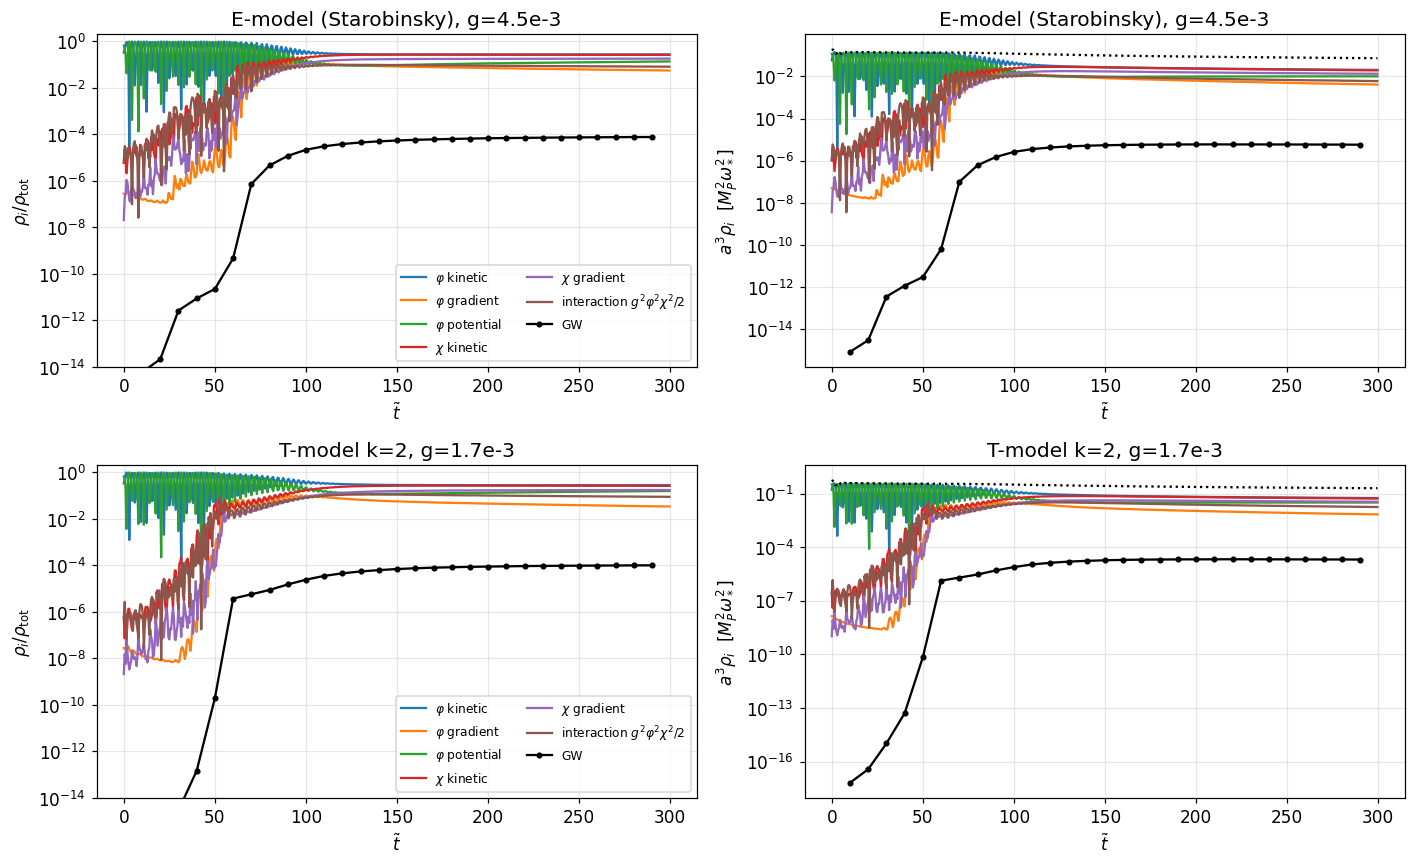

In [3]:
COMP = [
    (r"$\varphi$ kinetic", "E^kin_scal0"),
    (r"$\varphi$ gradient", "E^grad_scal0"),
    (r"$\varphi$ potential", "Vpot_term_0"),
    (r"$\chi$ kinetic", "E^kin_scal1"),
    (r"$\chi$ gradient", "E^grad_scal1"),
    (r"interaction $g^2\varphi^2\chi^2/2$", "Vpot_term_1"),
]

fig, axes = plt.subplots(len(data), 2, figsize=(13, 4 * len(data)), squeeze=False)
for row, (name, r) in zip(axes, data.items()):
    E, GW = r["E"], r["GW"]
    t, tot = E["t"], E["E_tot"]
    a3 = np.interp(t, r["a"]["t"], r["a"]["a"]) ** 3
    for lab, key in COMP:
        row[0].semilogy(t, np.abs(E[key]) / tot, label=lab)
        row[1].semilogy(t, np.abs(E[key]) * a3, label=lab)
    m = GW["t"] > 0
    row[0].semilogy(GW["t"][m], GW["rhoGW_over_rho"][m], "k-o", ms=3, label="GW")
    a3gw = np.interp(GW["t"][m], r["a"]["t"], r["a"]["a"]) ** 3
    row[1].semilogy(GW["t"][m], GW["rhoGW"][m] * a3gw, "k-o", ms=3, label="GW")
    row[1].semilogy(t, tot * a3, "k:", lw=1.5, label="total")
    row[0].set_ylim(1e-14, 2); row[0].set_ylabel(r"$\rho_i/\rho_{\rm tot}$")
    row[1].set_ylabel(r"$a^3\rho_i$  [$M_P^2\omega_*^2$]")
    for ax in row:
        ax.set_xlabel(r"$\tilde t$"); ax.set_title(name)
    row[0].legend(fontsize=8, ncol=2, loc="lower right")
fig.tight_layout()

### Equation of state and energy conservation
$w=p/\rho$ with $p = \rho_{\rm kin}-\rho_{\rm grad}/3-V$ (scalar fields only). The Friedmann-constraint violation from `average_energy_conservation.txt` checks the run's accuracy.

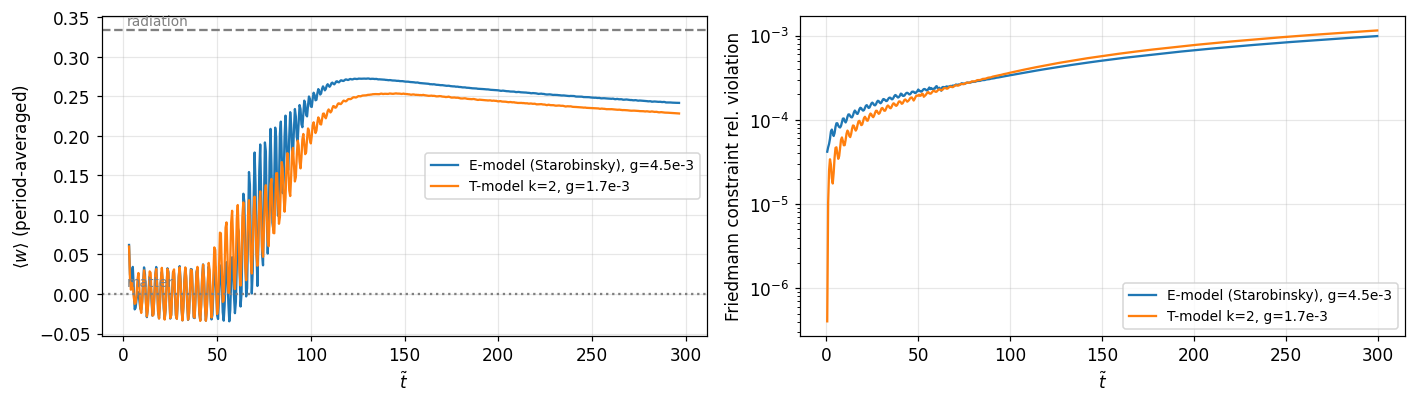

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(13, 3.8))
for name, r in data.items():
    E = r["E"]
    kin = E["E^kin_scal0"] + E["E^kin_scal1"]
    grad = E["E^grad_scal0"] + E["E^grad_scal1"]
    V = E["Vpot_term_0"] + E["Vpot_term_1"]
    w = (kin - grad / 3 - V) / E["E_tot"]
    # running average over ~one oscillation period (2 pi in program time)
    dt = E["t"][1] - E["t"][0]
    nwin = max(1, int(round(2 * np.pi / dt)))
    wavg = np.convolve(w, np.ones(nwin) / nwin, mode="valid")  # drop the edges where the window is incomplete
    tavg = E["t"][nwin // 2: nwin // 2 + len(wavg)]
    axes[0].plot(tavg, wavg, label=name)
    c = r["cons"]
    axes[1].semilogy(c["t"][1:], np.abs(c["rel_diff_friedmann"][1:]), label=name)
axes[0].axhline(0, c="gray", ls=":"); axes[0].axhline(1 / 3, c="gray", ls="--")
axes[0].text(2, 0.34, "radiation", fontsize=9, color="gray"); axes[0].text(2, 0.01, "matter", fontsize=9, color="gray")
axes[0].set_xlabel(r"$\tilde t$"); axes[0].set_ylabel(r"$\langle w\rangle$ (period-averaged)"); axes[0].legend(fontsize=9)
axes[1].set_xlabel(r"$\tilde t$"); axes[1].set_ylabel("Friedmann constraint rel. violation"); axes[1].legend(fontsize=9)
fig.tight_layout()

## 3. Field spectra
$\Delta_{\tilde f}(k)$ of the inflaton and the daughter field at each output time (every $\Delta\tilde t=10$); the colour shows time. $k$ is comoving, in units of $\omega_*$.

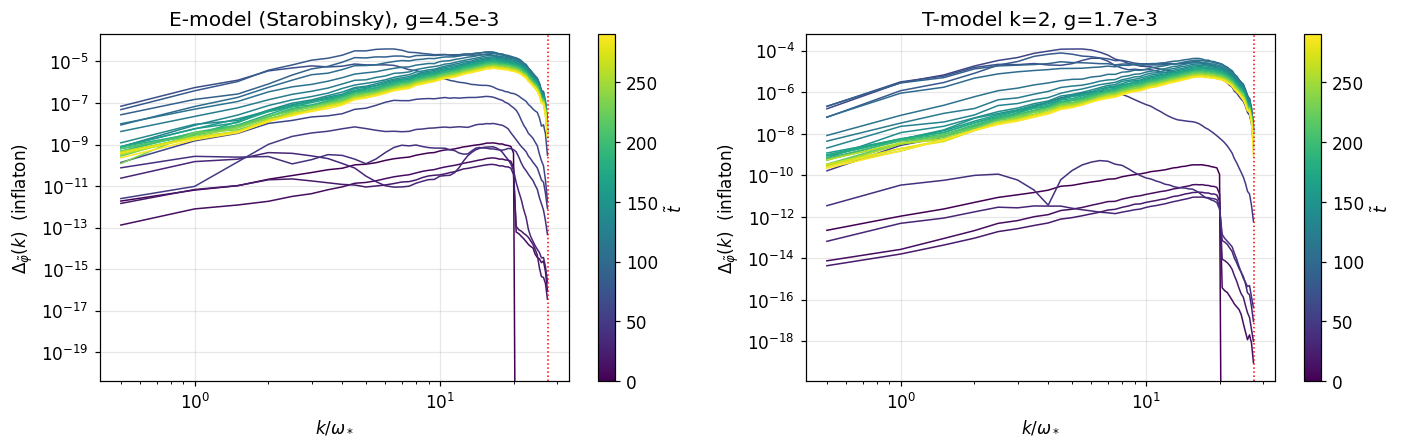

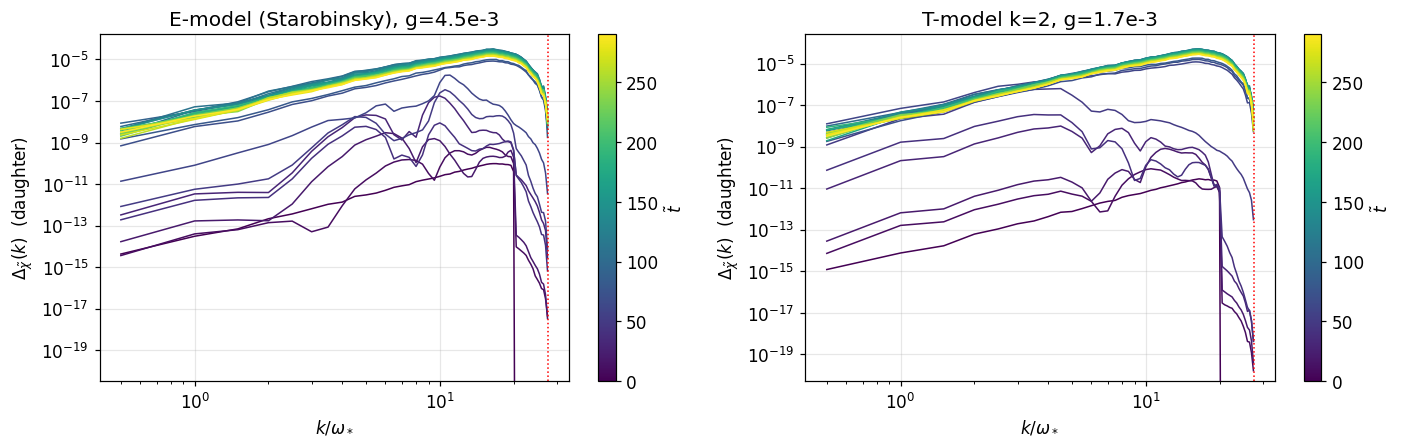

In [5]:
def plot_spectra(key, ylabel, col=1):
    fig, axes = plt.subplots(1, len(data), figsize=(6.5 * len(data), 4.2), squeeze=False)
    for ax, (name, r) in zip(axes[0], data.items()):
        ts, blocks = r["t_s"], r[key]
        norm = colors.Normalize(ts.min(), ts.max())
        vmax = max(b[:, col].max() for b in blocks)
        for t, b in zip(ts, blocks):
            k, v = b[:, 0], b[:, col]
            m = v > 0
            ax.loglog(k[m], v[m], color=cm.viridis(norm(t)), lw=1)
        ax.set_ylim(vmax * 1e-16, vmax * 5)  # the t=0 spectra drop to ~1e-40 above kCutOff
        ax.axvline(np.sqrt(3) * 64 * 0.5 / 2, c="r", ls=":", lw=1)  # k_max of the lattice
        ax.set_xlabel(r"$k/\omega_*$"); ax.set_ylabel(ylabel); ax.set_title(name)
        fig.colorbar(cm.ScalarMappable(norm=norm, cmap="viridis"), ax=ax, label=r"$\tilde t$")
    fig.tight_layout()

plot_spectra("S_phi", r"$\Delta_{\tilde\varphi}(k)$  (inflaton)")
plot_spectra("S_chi", r"$\Delta_{\tilde\chi}(k)$  (daughter)")

Conjugate-momentum spectra $\Delta_{\tilde\pi}(k)$ (third column of the spectra files):

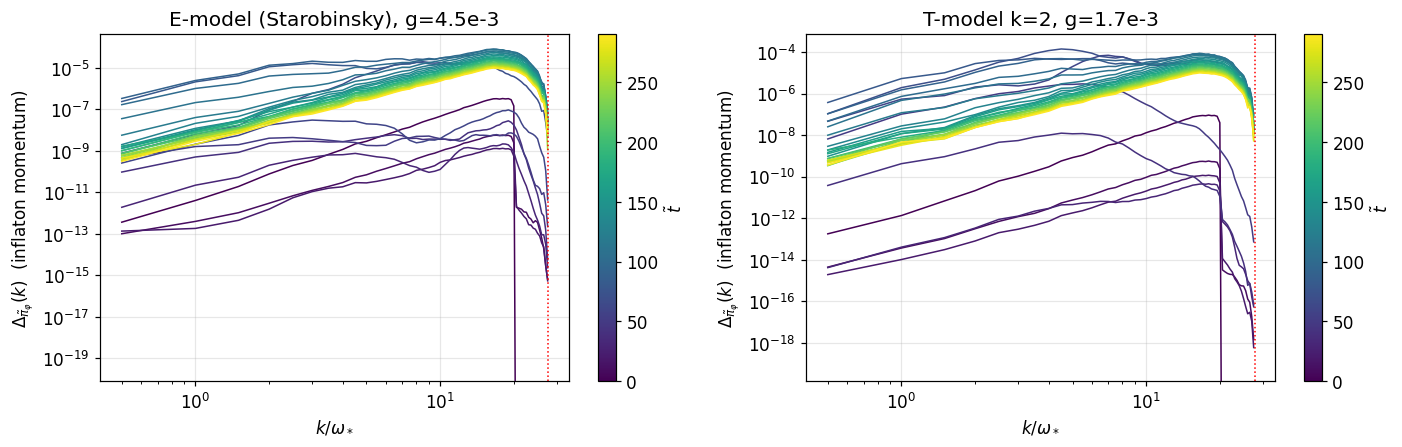

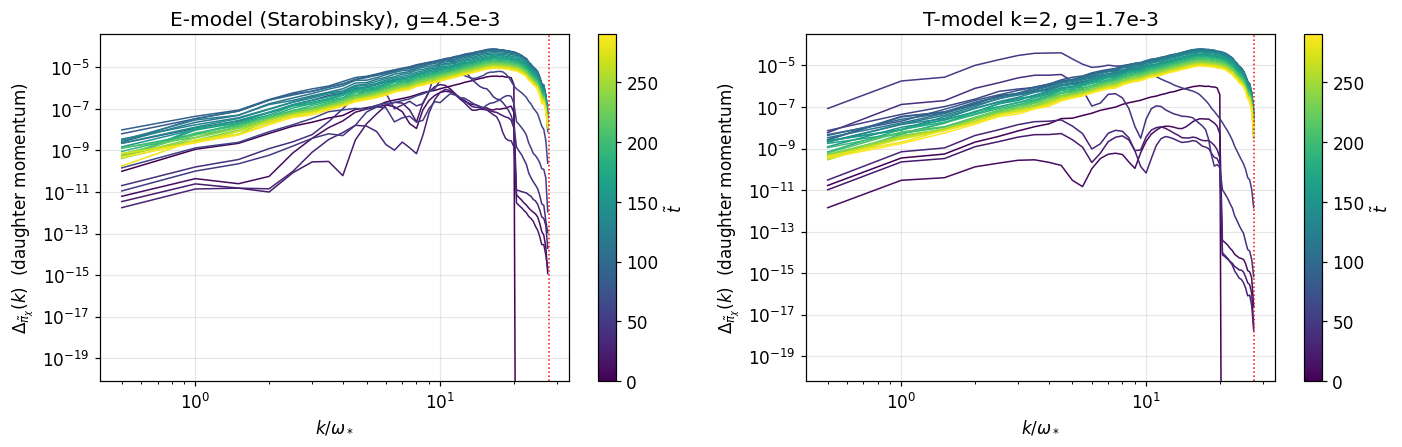

In [6]:
plot_spectra("S_phi", r"$\Delta_{\tilde\pi_\varphi}(k)$  (inflaton momentum)", col=2)
plot_spectra("S_chi", r"$\Delta_{\tilde\pi_\chi}(k)$  (daughter momentum)", col=2)

## 4. Gravitational-wave spectrum
$\Omega_{\rm GW}(k,\tilde t)=\frac{1}{\rho_{\rm tot}}\frac{d\rho_{\rm GW}}{d\ln k}$ at each output time; its integral over $\ln k$ is the GW energy fraction plotted in Sec. 2.

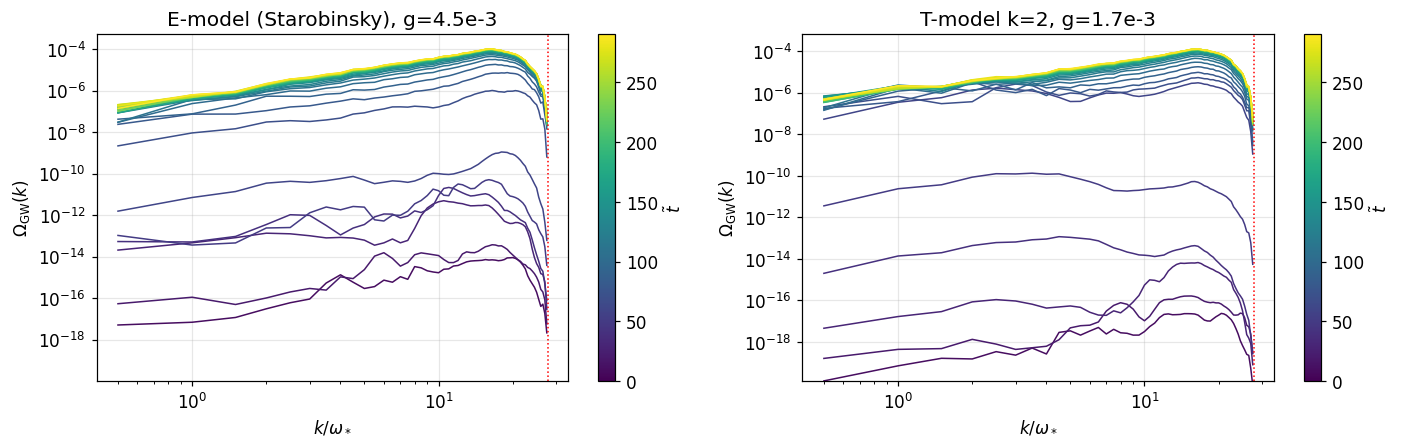

In [7]:
plot_spectra("S_gw", r"$\Omega_{\rm GW}(k)$")

### Final spectra: E-model vs T-model

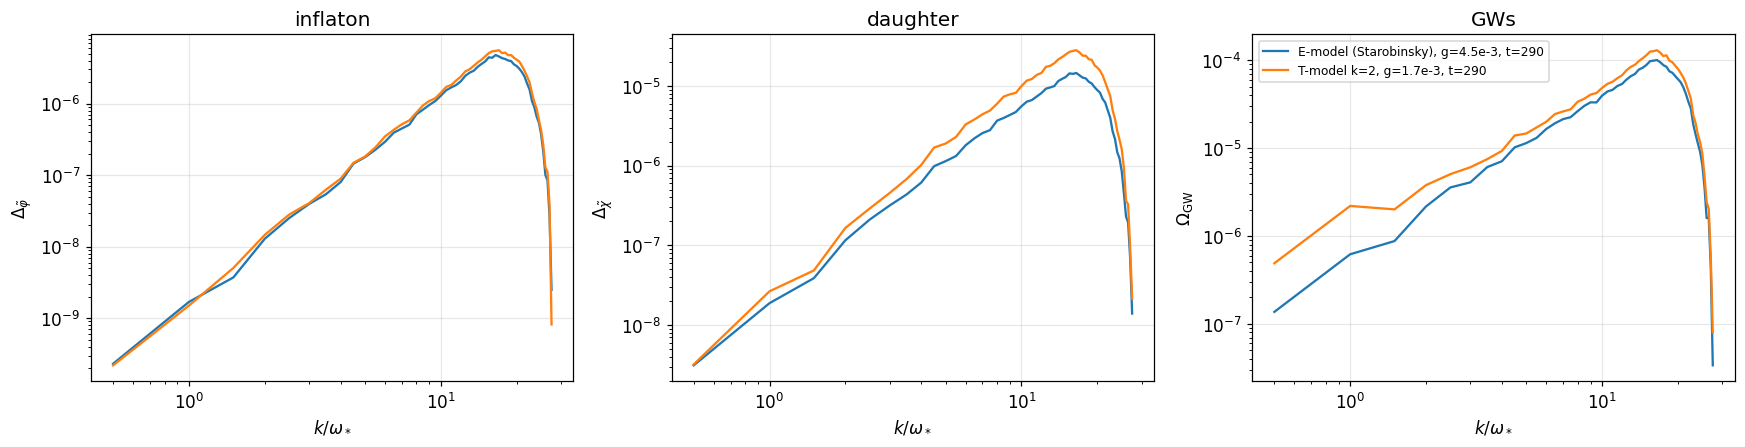

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.2))
for name, r in data.items():
    for ax, key, lab in zip(axes, ["S_phi", "S_chi", "S_gw"],
                            [r"$\Delta_{\tilde\varphi}$", r"$\Delta_{\tilde\chi}$", r"$\Omega_{\rm GW}$"]):
        b = r[key][-1]; m = b[:, 1] > 0
        ax.loglog(b[m, 0], b[m, 1], label=f"{name}, t={r['t_s'][-1]:.0f}")
        ax.set_xlabel(r"$k/\omega_*$"); ax.set_ylabel(lab)
axes[0].set_title("inflaton"); axes[1].set_title("daughter"); axes[2].set_title("GWs")
axes[2].legend(fontsize=8)
fig.tight_layout()

## 5. Cosmological redshifting: frequency and spectrum today

Following Figueroa & Torrenti, *Gravitational wave production from preheating: parameter dependence*, JCAP 10 (2017) 057, [arXiv:1707.04533](https://arxiv.org/abs/1707.04533), Sec. 2.1, Eqs. (2.16)–(2.18).
GWs decouple once produced, so after the end of production $t_{\rm f}$ the mode $k$ simply redshifts. With $t_{\rm i}$ the start of the simulation (end of inflation, $a_{\rm i}=1$), $t_{\rm RD}$ the onset of radiation domination (RD), and $t_o$ today:

**Frequency today** (Eq. 2.17, first line):
$$
f=\frac{a_{\rm i}}{a_o}\frac{k}{2\pi}
=\epsilon_{\rm i}^{1/4}\left(\frac{g_{s,o}}{g_{s,\rm RD}}\right)^{1/3}\left(\frac{g_o}{g_{\rm RD}}\right)^{-1/4}\left(\frac{\rho_o}{\rho_{\rm i}}\right)^{1/4}\frac{k}{2\pi},
\qquad
\epsilon_{\rm i}\equiv\left(\frac{a_{\rm i}}{a_{\rm RD}}\right)^{1-3w}.
$$

**Amplitude today** (Eq. 2.18, first line):
$$
h^2\Omega_{\rm GW}(f)=h^2\Omega_{\rm rad}\left(\frac{a_{\rm f}}{a_{\rm RD}}\right)^{1-3w}\left(\frac{g_{s,o}}{g_{s,\rm RD}}\right)^{4/3}\left(\frac{g_{\rm RD}}{g_o}\right)\Omega_{\rm GW}^{(\rm f)}(k).
$$

**Implementation choices**
- $k$ is comoving with $a_{\rm i}=1$: $k\,[{\rm GeV}]=\tilde k\,\omega_*$. Also $\rho_{\rm i}=\tilde E_{\rm tot}(0)\,M_P^2\omega_*^2$ and $\omega_*=\sqrt{\lambda_k}\,M_P\,x_i^{(k-2)/2}$, as in the model headers (for $k=2$: $\omega_*=m_\varphi$).
- For a non-constant $w$ the factors $(a/a_{\rm RD})^{1-3w}$ become $\exp[-\int(1-3w)\,d\ln a]$. The integral from $a_{\rm i}$ to $a_{\rm f}$ is computed **from the lattice $w(t)$**.
- After the run, the universe is assumed to take $N_{\rm post}=\ln(a_{\rm RD}/a_{\rm f})$ more $e$-folds with constant $w_{\rm post}$ before becoming RD. The default is $N_{\rm post}=0$ (instant RD after the run). This is an **upper bound** on frequency and amplitude, because $w\approx0.24<1/3$ at the end of the runs; set $N_{\rm post}>0$ to see the suppression.
- Constants: $\rho_o=\frac{\pi^2}{30}g_oT_0^4=3.36\times10^{-15}\,{\rm eV}^4$ ($T_0=2.7255$ K, $g_o=3.36$, $g_{s,o}=3.91$), $h^2\Omega_{\rm rad}=4.15\times10^{-5}$ (consistent with this $\rho_o$), $g_{\rm RD}=g_{s,\rm RD}=106.75$ (SM).
- Note: the paper's numerical shortcut "$f\simeq\epsilon_{\rm i}^{1/4}(k/\rho_{\rm i}^{1/4})\times8\cdot10^9$ Hz" is a factor $2\pi$ below what its own first line gives: with $\rho_o=2\cdot10^{-15}$ eV$^4$ one gets $\rho_o^{1/4}/(2\pi)=5.1\times10^{10}$ Hz. We use the exact first line, which reproduces the standard $f\simeq4\times10^{10}\,(k/\rho_{\rm i}^{1/4})$ Hz of Dufaux et al. (2007) for $\epsilon_{\rm i}=1$.

In [9]:
# --- Constants -------------------------------------------------------------
MP = 2.435e18                        # reduced Planck mass [GeV]
GEV_TO_HZ = 1.519267e24 / (2 * np.pi)  # k[GeV] -> k/(2 pi) [Hz]  (1 GeV/hbar = 1.519e24 s^-1)
T0_GEV = 2.7255 * 8.617333e-14         # CMB temperature today [GeV]
G_O, GS_O = 3.36, 3.91                 # relativistic / entropic d.o.f. today
G_RD = GS_RD = 106.75                  # d.o.f. at the onset of RD (SM)
RHO_O = np.pi**2 / 30 * G_O * T0_GEV**4  # radiation energy density today [GeV^4]
H2_OMEGA_RAD = 4.15e-5

# --- Expansion after the simulation until RD (assumption) ---------------------
N_POST = 0.0     # e-folds between the end of the run and the onset of RD (0 = instant RD: upper bound)
W_POST = 1 / 3   # equation of state in that phase (irrelevant if N_POST = 0)


def read_params(d):
    p = {}
    with open(os.path.join(d, "run.in")) as f:
        for line in f:
            line = line.split("#")[0].strip()
            if "=" in line:
                key, val = [s.strip() for s in line.split("=", 1)]
                p[key] = val.split()
    return p


def omega_star(d):
    # Same rescaling as models/attractorE.h and models/attractorT.h
    p = read_params(d)
    lam, alpha_att, k = float(p["lambda"][0]), float(p.get("alphaAtt", ["1"])[0]), float(p.get("k", ["2"])[0])
    b = np.sqrt(2 / (3 * alpha_att)); c = b / 2
    coef = b if os.path.basename(d).startswith("E_") else c   # run folders are named E_* / T_*
    lam_k = k * 0.75 * lam * coef**k
    xi = abs(float(p["initial_amplitudes"][0])) / MP
    return np.sqrt(lam_k) * MP * xi ** ((k - 2) / 2)


def expansion_integral(r):
    # I(t) = int_{a_i}^{a(t)} (1 - 3w) dln a from the lattice energies (scalar fields; GWs are negligible)
    E = r["E"]
    kin = E["E^kin_scal0"] + E["E^kin_scal1"]
    grad = E["E^grad_scal0"] + E["E^grad_scal1"]
    V = E["Vpot_term_0"] + E["Vpot_term_1"]
    w = (kin - grad / 3 - V) / E["E_tot"]
    lna = np.log(np.interp(E["t"], r["a"]["t"], r["a"]["a"]))
    I = np.concatenate([[0], np.cumsum(0.5 * (2 - 3 * (w[1:] + w[:-1])) * np.diff(lna))])
    return E["t"], I


def gw_today(name, idx=-1):
    # Return f [Hz], h^2 Omega_GW today for spectrum number idx (production assumed to end at that time).
    r, d = data[name], RUNS[name]
    ws = omega_star(d)
    rho_i = r["E"]["E_tot"][0] * MP**2 * ws**2                    # GeV^4
    t, I = expansion_integral(r)
    t_f = r["t_s"][idx]
    I_f = np.interp(t_f, t, I)                                       # int_i^f (1-3w) dln a
    I_post = (1 - 3 * W_POST) * N_POST                               # int_f^RD (1-3w) dln a
    eps_i = np.exp(-(I_f + I_post))                                  # (a_i/a_RD)^(1-3w)
    eps_f = np.exp(-I_post)                                          # (a_f/a_RD)^(1-3w)
    b = r["S_gw"][idx]
    k_gev = b[:, 0] * ws
    f = eps_i**0.25 * (GS_O / GS_RD)**(1/3) * (G_O / G_RD)**(-1/4) * (RHO_O / rho_i)**0.25 * k_gev * GEV_TO_HZ
    h2omega = H2_OMEGA_RAD * eps_f * (GS_O / GS_RD)**(4/3) * (G_RD / G_O) * b[:, 1]
    info = dict(omega_star=ws, rho_i=rho_i, eps_i=eps_i, eps_f=eps_f, t_f=t_f,
                f_per_k=f[0] / b[0, 0], a_f=np.interp(t_f, r["a"]["t"], r["a"]["a"]))
    return f, h2omega, info


for name in data:
    f, h2o, info = gw_today(name)
    m = h2o > 0
    ip = np.argmax(h2o)
    print(f"{name}:\n  omega_* = {info['omega_star']:.3e} GeV, rho_i^(1/4) = {info['rho_i']**0.25:.3e} GeV, "
          f"t_f = {info['t_f']:.0f}, a_f = {info['a_f']:.2f}\n"
          f"  eps_i = (a_i/a_RD)^(1-3w) = {info['eps_i']:.3f},  (a_f/a_RD)^(1-3w) = {info['eps_f']:.3f}\n"
          f"  f/k_tilde = {info['f_per_k']:.3e} Hz,  peak: f_p = {f[ip]:.2e} Hz, h^2 Omega_GW(f_p) = {h2o[ip]:.2e}")

E-model (Starobinsky), g=4.5e-3:
  omega_* = 3.349e+13 GeV, rho_i^(1/4) = 5.842e+15 GeV, t_f = 290, a_f = 18.86
  eps_i = (a_i/a_RD)^(1-3w) = 0.126,  (a_f/a_RD)^(1-3w) = 1.000
  f/k_tilde = 1.568e+08 Hz,  peak: f_p = 2.59e+09 Hz, h^2 Omega_GW(f_p) = 1.60e-09
T-model k=2, g=1.7e-3:
  omega_* = 1.756e+13 GeV, rho_i^(1/4) = 5.468e+15 GeV, t_f = 290, a_f = 26.08
  eps_i = (a_i/a_RD)^(1-3w) = 0.094,  (a_f/a_RD)^(1-3w) = 1.000
  f/k_tilde = 8.163e+07 Hz,  peak: f_p = 1.35e+09 Hz, h^2 Omega_GW(f_p) = 2.07e-09


### GW spectrum today: time evolution
Each curve is the spectrum at one output time, redshifted to today as if production stopped at that time. The $k\to f$ map changes slightly with $t_{\rm f}$ through $\epsilon_{\rm i}$.

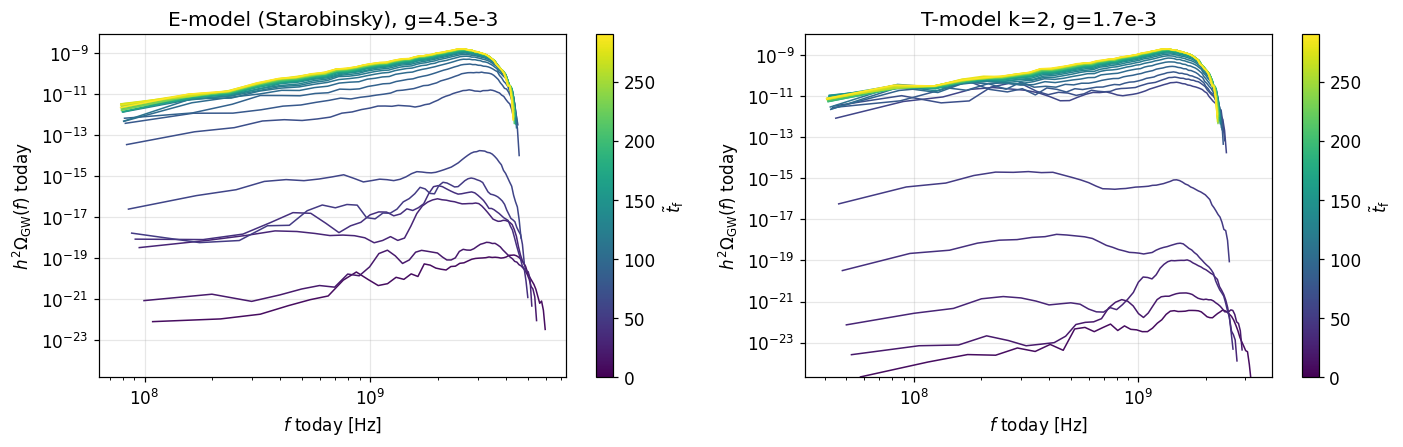

In [10]:
fig, axes = plt.subplots(1, len(data), figsize=(6.5 * len(data), 4.2), squeeze=False)
for ax, name in zip(axes[0], data):
    ts = data[name]["t_s"]
    norm = colors.Normalize(ts.min(), ts.max())
    vmax = 0
    for i, t in enumerate(ts):
        f, h2o, _ = gw_today(name, i)
        m = h2o > 0
        ax.loglog(f[m], h2o[m], color=cm.viridis(norm(t)), lw=1)
        vmax = max(vmax, h2o.max())
    ax.set_ylim(vmax * 1e-16, vmax * 5)
    ax.set_xlabel(r"$f$ today [Hz]"); ax.set_ylabel(r"$h^2\Omega_{\rm GW}(f)$ today"); ax.set_title(name)
    fig.colorbar(cm.ScalarMappable(norm=norm, cmap="viridis"), ax=ax, label=r"$\tilde t_{\rm f}$")
fig.tight_layout()

### Final spectra today: E-model vs T-model
Final ($\tilde t_{\rm f}=290$) field spectra versus the frequency today of the corresponding comoving mode, and the GW spectrum today, $h^2\Omega_{\rm GW}(f)$. The dashed curves show the effect of an extra matter-dominated phase of $N_{\rm post}=2$ $e$-folds before RD.
The vertical dotted lines mark $k_{\max}$ of the lattice: the region near it is not converged (see the notes below).

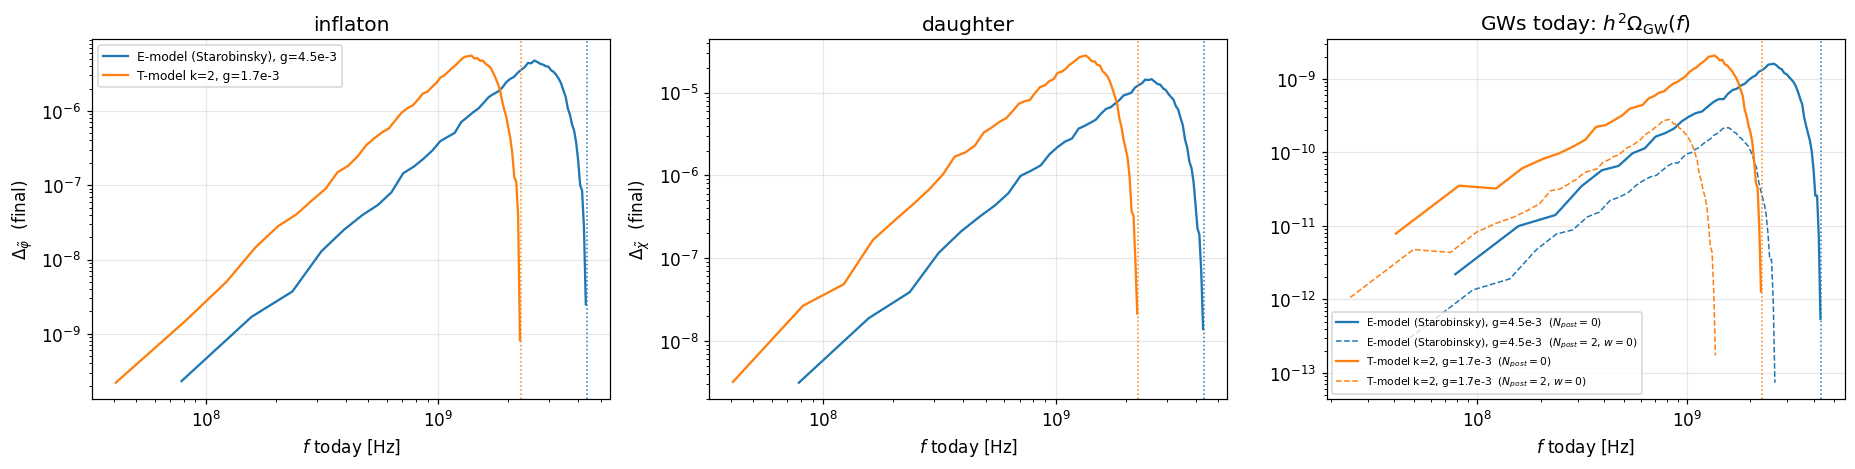

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(17, 4.4))
kmax_tilde = np.sqrt(3) * 64 * 0.5 / 2
for j, name in enumerate(data):
    r = data[name]
    col = f"C{j}"
    f, h2o, info = gw_today(name)
    fk = info["f_per_k"]                                  # Hz per unit k_tilde (same map for all fields)
    for ax, key, lab in zip(axes[:2], ["S_phi", "S_chi"], [r"$\Delta_{\tilde\varphi}$", r"$\Delta_{\tilde\chi}$"]):
        b = r[key][-1]; m = b[:, 1] > 0
        ax.loglog(b[m, 0] * fk, b[m, 1], col, label=name)
        ax.set_ylabel(lab + "  (final)")
    m = h2o > 0
    axes[2].loglog(f[m], h2o[m], col, label=f"{name}  ($N_{{post}}=0$)")
    # sensitivity to a matter-dominated phase after the run (w=0, 2 e-folds)
    N_save, W_save = N_POST, W_POST
    N_POST, W_POST = 2.0, 0.0
    f2, h2o2, _ = gw_today(name)
    N_POST, W_POST = N_save, W_save
    axes[2].loglog(f2[m], h2o2[m], col, ls="--", lw=1, label=f"{name}  ($N_{{post}}=2$, $w=0$)")
    for ax in axes:
        ax.axvline(kmax_tilde * fk, c=col, ls=":", lw=1)
for ax in axes:
    ax.set_xlabel(r"$f$ today [Hz]")
axes[0].set_title("inflaton"); axes[1].set_title("daughter"); axes[2].set_title(r"GWs today: $h^2\Omega_{\rm GW}(f)$")
axes[0].legend(fontsize=8); axes[2].legend(fontsize=7)
fig.tight_layout()

## Notes and caveats
- **These runs are UV-limited.** $N=64$ with $k_{\rm IR}=0.5$ gives $k_{\max}\simeq\sqrt3\,N k_{\rm IR}/2\simeq28$ (red dotted line). The resonance band ($k\lesssim q_0^{1/4}m\sim10$) is resolved. But after backreaction ($\tilde t\gtrsim100$) the daughter, inflaton and GW spectra keep growing towards $k_{\max}$, and $\Omega_{\rm GW}$ peaks at $k\simeq17$, close to the cutoff. Peak position, amplitude and the final $\rho_{\rm GW}/\rho\sim10^{-4}$ are therefore **not converged**. Repeat at $N=128$–256 with the same $k_{\rm IR}$ (larger $k_{\max}$) before quoting numbers.
- The slow drift of the Friedmann-constraint violation to $10^{-3}$ is a sign of the same UV saturation.
- The early GW signal (before the resonance) is dominated by the initial vacuum fluctuations, which have a UV cutoff at `kCutOff = 20`.
- In Secs. 1–4, $\Omega_{\rm GW}$ is evaluated at the time of the simulation; Sec. 5 redshifts it to today. Today's values depend on the unknown expansion history between the end of the run and the onset of RD ($N_{\rm post}$, $w_{\rm post}$). The default (instant RD) is an upper bound.